In [139]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
min_lambda = vp / 1e9  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = Ny = 200
dx = dy = 0.1 * min_lambda
dt = 0.9 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 500
L = Nx * dx
T = Nt * dt

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(Nt // 6, Nt - 5, 6, dtype=int)
Ez_snapshots = []

cx, cy = Nx // 2, Ny // 2
px, py = cx + 1, cy + 1 # pontas de prova

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# --- campos ---
Ez_curr = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

# ---- parâmetros da PML -----
Npml = 60
m = 3 # ordem polinomial                 
R0 = 1e-8 # reflexão alvo
sigma_max_x = -1 * (m + 1) * np.log(R0) / (2 * np.sqrt(mu / eps) * Npml * dx)
sigma_max_y = -1 * (m + 1) * np.log(R0) / (2 * np.sqrt(mu / eps) * Npml * dy)

# ---- vetores para salvar os sigmas -----
# sigma = 0 dentro da regiao, diferente de zero na PML
sigma_x = np.zeros(Nx + 1)
sigma_y = np.zeros(Ny)

for i in range(Npml):
    x = (Npml - i) / Npml
    sigma_x[i] = sigma_max_x * x**m
    sigma_x[Nx - i] = sigma_max_x * x**m

for j in range(Npml):
    y = (Npml - j) / Npml
    sigma_y[j] = sigma_max_y * y**m
    sigma_y[Ny - j - 1] = sigma_max_y * y**m

# buffer de integração
I_curr = I_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# marcha no tempo
for n in range(Nt-1):
    # calcula os coeficientes
    F1_x = ((2 * eps - dt * sigma_x[:]) / (2 * eps + dt * sigma_x[:]))
    F2_x = (1 / mu) * ( (2 * eps * dt) / (2 * eps + dt * sigma_x[:] ) )

    F1_y = ((2 * eps - dt * sigma_y[:]) / (2 * eps + dt * sigma_y[:]))
    F2_y = (1 / mu) * ( (2 * eps * dt) / (2 * eps + dt * sigma_y[:] ) )

    sigma_y_appended = np.append(sigma_y, [sigma_y[-1]])
    sigma_e = (sigma_x[1:-1][:, None] + sigma_y_appended[1:-1][None, :]) / 2
    G1 = (2 * eps - dt * sigma_e) / (2 * eps + dt * sigma_e)
    G2 = 2 * dt / (2 * eps + dt * sigma_e)

    Hy_next[:, :] = F1_x * Hy_curr[:, :] + F2_x * (
        (Ez_curr[1:, :] - Ez_curr[:-1, :]) / dx
    )

    Hx_next[:, :] = F1_y * Hx_curr[:, :] - F2_y * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    ) / dy + (sigma_y[:] * (dt ** 2) / (mu * eps)) * I_curr[:, :]
        
    # Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
    #     Ez_curr[:, 1:] - Ez_curr[:, :-1]
    # ) + (sigma_x[1:] * (dt ** 2) / (mu * eps)) * I_curr[:, :]

    Ez_next[1:-1, 1:-1] = G1 * Ez_curr[1:-1, 1:-1] + G2 * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx
        - (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # Ez_next[1:-1, 1:-1] = G1 * Ez_curr[1:-1, 1:-1] + G2 * (
    #     (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
    #     (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    # )

    I_next[:, :] = I_curr[:, :] + (Ez_curr[:, 1:] - Ez_curr[:, :-1])

    # --- fontes ---
    frequency = 1e9
    source_gaussiano = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)
    Ez_next[cx, cy] = source_gaussiano

    # PEC nas bordas externas do grid
    Ez_next[0, :] = Ez_next[Nx, :] = Ez_next[:, 0] = Ez_next[:, Ny] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez_next[px, py])

    # atualiza os campos para o próximo passo
    Ez_curr, Ez_next = Ez_next, Ez_curr
    Hx_curr, Hx_next = Hx_next, Hx_curr
    Hy_curr, Hy_next = Hy_next, Hy_curr
    I_curr, I_next = I_next, I_curr

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez_curr.copy())


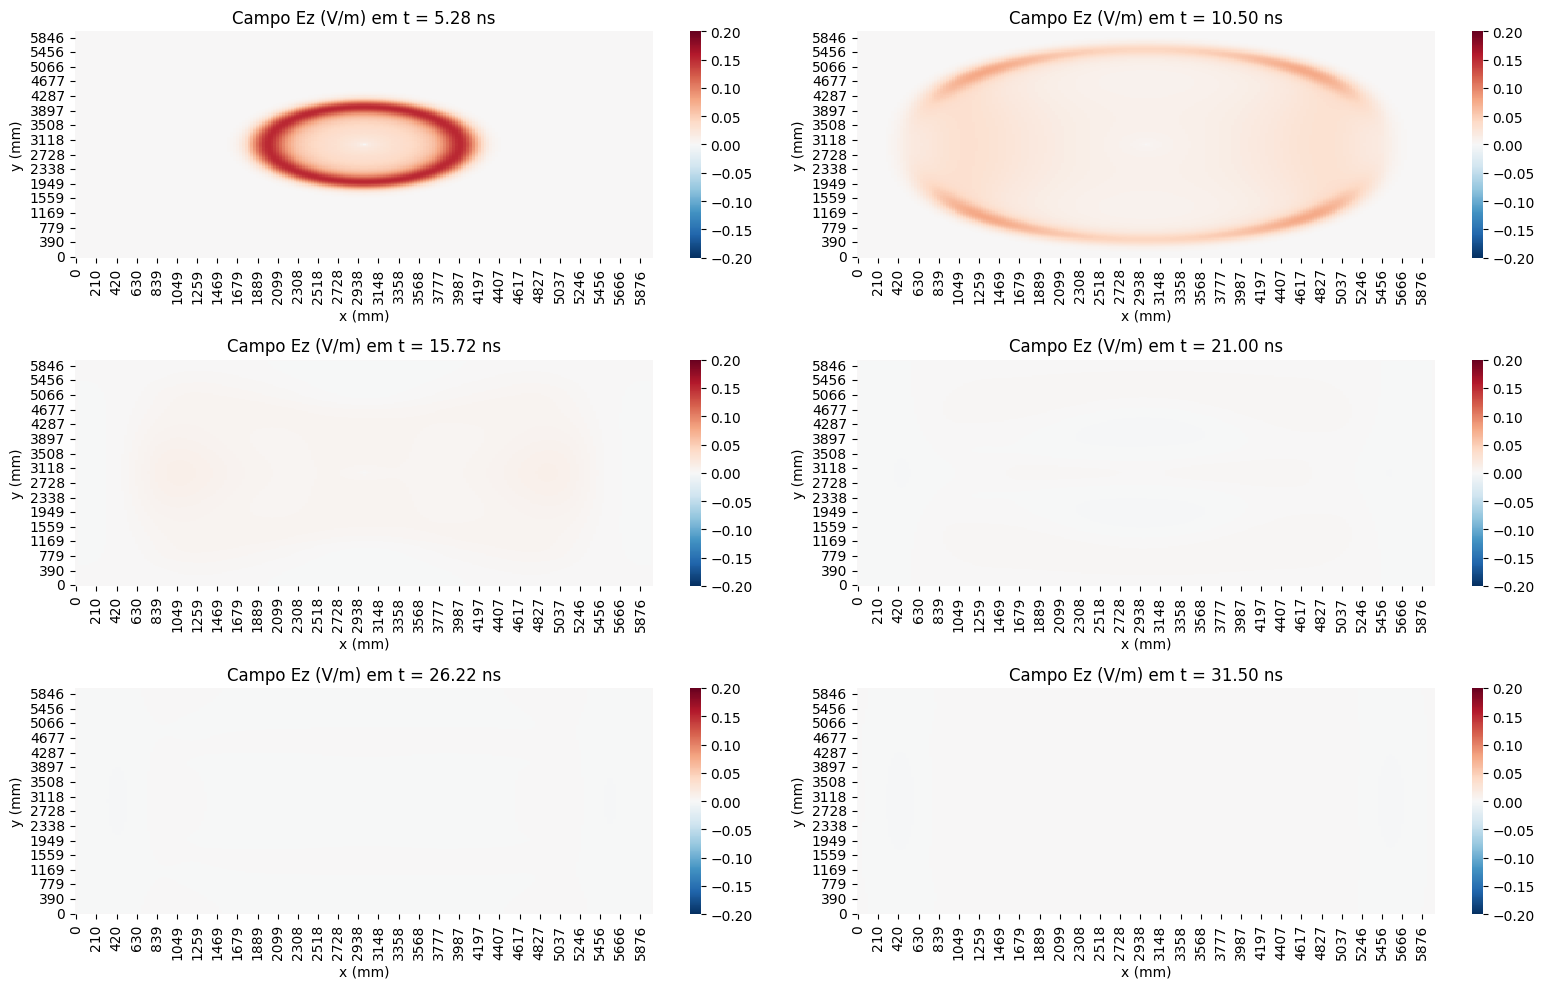

In [140]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.2, vmax=0.2,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

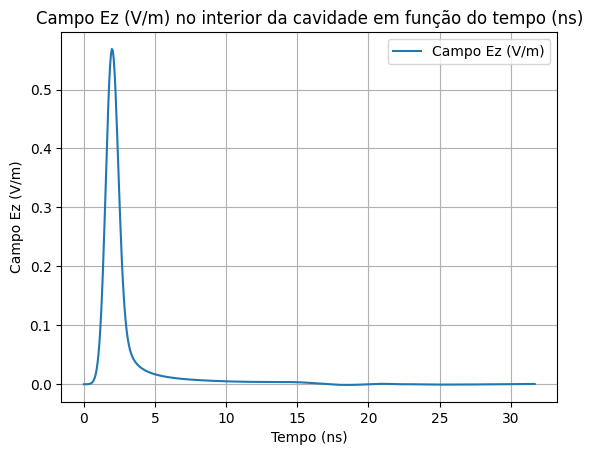

In [141]:
# plt.plot(grid_t_Ez[Nt//2:-2] * 1e9, probe[Nt//2:], label="Campo Ez (V/m)")
plt.plot(grid_t_Ez[:-2] * 1e9, probe[:], label="Campo Ez (V/m)")
plt.title(fr"Campo Ez (V/m) no interior da cavidade em função do tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()